In [1]:
import warnings
import argparse
warnings.filterwarnings("ignore")

import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.metrics import adjusted_rand_score
import GSG


cmap = cm.get_cmap('tab20')
colors = [cmap(i) for i in range(20)]
def rgba_to_hex(rgba):
    r, g, b, a = rgba
    return '#{:02X}{:02X}{:02X}'.format(int(r*255), int(g*255), int(b*255))
hex_colors1 = [rgba_to_hex(c) for c in colors]

cmap = cm.get_cmap('tab20b')
colors = [cmap(i) for i in range(20)]
def rgba_to_hex(rgba):
    r, g, b, a = rgba
    return '#{:02X}{:02X}{:02X}'.format(int(r*255), int(g*255), int(b*255))
hex_colors2 = [rgba_to_hex(c) for c in colors]
hex_colors = hex_colors1 + hex_colors2

In [2]:
parser = argparse.ArgumentParser(description="GAT")
parser.add_argument("--seeds", type=int, default=0)
parser.add_argument("--device", type=int, default=-1)

# Model parameters
parser.add_argument("--imputation", type=bool, default=False, help = "Domain or imputation")
parser.add_argument("--mask_rate", type=float, default=0.8)
parser.add_argument("--replace_rate", type=float, default=0.05)
parser.add_argument("--in_drop", type=float, default=0.2, help="input feature dropout")
parser.add_argument("--num_hidden", type=int, default=128, help="number of hidden units")
parser.add_argument("--num_layers", type=int, default=3, help="number of hidden layers")
parser.add_argument("--activation", type=str, default="elu")
parser.add_argument("--norm", type=str, default="batchnorm")
parser.add_argument("--alpha_l", type=float, default=4, help="`pow`inddex for `sce` loss")

# Training parameters
parser.add_argument("--load_model", action="store_true")
parser.add_argument("--save_model", action="store_true")
parser.add_argument("--max_epoch", type=int, default=500, help="number of training epochs")
parser.add_argument("--optimizer", type=str, default="adam")
parser.add_argument("--lr", type=float, default=0.001, help="learning rate")
parser.add_argument("--weight_decay", type=float, default=2e-4, help="weight decay")


# Dataset parameter
parser.add_argument("--folder_name", type=str, default="/home/sunhang/Embedding/Spatial_dataset/10X/")
parser.add_argument("--sample_name", type=str, default="V1_Breast_Cancer_Block_A_Section_1")
parser.add_argument("--cluster_label", type=str, default= "fine_annot_type")
parser.add_argument("--num_classes", type=int, default=7, help = "The number of clusters")

parser.add_argument("--feature_dim_method", type=str, default="PCA")
parser.add_argument("--num_features", type=int, default=600)
parser.add_argument("--graph", type=str, default="radius")
parser.add_argument("--num_neighbors", type=int, default=50)
parser.add_argument("--threshold_radius", type=int, default=25)

# read parameters
args = parser.parse_args(args=[])
print(args)

Namespace(activation='elu', alpha_l=4, cluster_label='fine_annot_type', device=-1, feature_dim_method='PCA', folder_name='/home/sunhang/Embedding/Spatial_dataset/10X/', graph='radius', imputation=False, in_drop=0.2, load_model=False, lr=0.001, mask_rate=0.8, max_epoch=500, norm='batchnorm', num_classes=7, num_features=600, num_hidden=128, num_layers=3, num_neighbors=50, optimizer='adam', replace_rate=0.05, sample_name='V1_Breast_Cancer_Block_A_Section_1', save_model=False, seeds=0, threshold_radius=25, weight_decay=0.0002)


In [3]:
adata = GSG.pp.read_10X_Visium_with_label(args.folder_name + args.sample_name)
num_classes = adata.obs[args.cluster_label].nunique()

adata, graph = GSG.pp.Graph_10X(adata, args)
adata, model = GSG.train.GSG_train(adata, graph, args)

100%|██████████| 22064/22064 [00:00<00:00, 640365.93it/s]
2026-06-18 16:14:34,875 - INFO - start training..
# Epoch 499: train_loss: 0.3339: 100%|██████████| 500/500 [00:51<00:00,  9.74it/s]


In [4]:
adata.obs["GSG_Kmeans_cluster"] = GSG.utils.KMeans_use(adata.obsm["GSG_embedding"], num_classes)
adata.obs["GSG_Kmeans_cluster_str"] = adata.obs["GSG_Kmeans_cluster"].astype(str)
ari = adjusted_rand_score(adata.obs[args.cluster_label].values, adata.obs['GSG_Kmeans_cluster_str'])
print(ari)

0.632262431047772


... storing 'annot_type' as categorical
... storing 'fine_annot_type' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


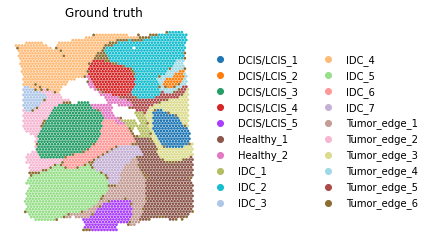

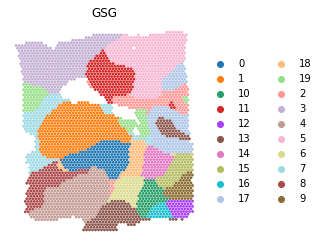

In [5]:
adata.obs["GSG_Kmeans_cluster_str"] = adata.obs["GSG_Kmeans_cluster_str"].astype('category')

sc.pl.embedding(adata, basis='spatial', color=args.cluster_label, title='Ground truth', frameon=False, show=False)
plt.gca().set_aspect(1)
plt.show()

sc.pl.embedding(adata, basis='spatial', color='GSG_Kmeans_cluster_str', title='GSG', frameon=False, show=False)
plt.gca().set_aspect(1)
plt.show()